## Experiment der Beschreibung von Hochwasser mit RF 

Skizze: 

Hochwasserereignis am Rhein mit Random Forest untersuchen:

Open-Source verfügbare Prädiktoren, welche auf ihre Relevanz getestet und mittels Feature Engineering verknüpft werden können:

Niederschläge, ET_p, ET_a, Lufttemperatur (DWD)
Hydrochemische Parameter des Rheins (Gütemessstellen: Sauerstoffgehalt, elek. Leitfähigkeit, Durchflusswerte, pH-Werte, Wassertemperatur)
Lagged Features: zb Niederschlag - 7 Tage
Bodenfeuchte?
ggfs. ergänzend Fernerkundungsdaten einbauen zb Sentinel-1 und Sentinel-2 (Grün, Rot, NDCI, NDVI, NDWI, SWIR)
Feature Importance prüfen, cross validation, SHAP values Analyse

Für den Ansatz testen wir als Prädiktoren Niederschläge (Station Sinzig) mit t, t-1, t-3 und t-7 sowie Pegeldaten des Pegels in Bonn mit t, t-1, t-3 und t-7.

In [69]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [43]:
df_pegel = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Pegeldaten_Bonn.csv", delimiter=";", header=0)

In [44]:
df_pegel

,Datum,t,t_minus1,t_minus_3,t_minus7
0,15.09.2009,162.489583,159.552083,172.041667,203.864583
1,16.09.2009,164.364583,162.489583,164.781250,196.010417
2,17.09.2009,159.812500,164.364583,159.552083,185.343750
3,18.09.2009,155.489583,159.812500,162.489583,178.000000
4,19.09.2009,147.791667,155.489583,164.364583,172.041667
...,...,...,...,...,...
6024,14.03.2026,282.416667,277.895833,280.552083,329.843750
6025,15.03.2026,314.239583,282.416667,276.989583,317.000000
6026,16.03.2026,317.864583,314.239583,277.895833,305.468750
6027,17.03.2026,311.125000,317.864583,282.416667,293.333333


In [19]:
df_pegel ["Datum"]

0       08.09.2009
1       09.09.2009
2       10.09.2009
3       11.09.2009
4       12.09.2009
           ...    
5541    13.03.2026
5542    14.03.2026
5543    15.03.2026
5544    16.03.2026
5545    17.03.2026
Name: Datum, Length: 5546, dtype: object

In [45]:
# die zeile ist auch wichtig fürs rf modell später 
df_pegel["Datum"] = pd.to_datetime(df_pegel["Datum"], format="%d.%m.%Y")

In [22]:
# Pegeldaten herrichten, fehlende Tage mitteln


df_pegel = df.sort_values("Datum")
full_range = pd.date_range(start="2009-09-08", end="2026-03-18", freq="D")


df_pegel = df_pegel.set_index("Datum").reindex(full_range)


df_pegel["t"] = df_pegel["t"].interpolate(method="linear")


df_pegel = df_pegel.reset_index().rename(columns={"index": "Datum"})
df_pegel["Datum"] = df_pegel["Datum"].dt.strftime("%d.%m.%Y")

df_pegel.to_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Pegeldaten_Bonn_filled.csv", index=False, header=False)

print("Fertig!")

Fertig!


Wie viele Tage gab es in unserem Datensatz? 

In [23]:
start = pd.to_datetime("08.09.2009", format="%d.%m.%Y")
end   = pd.to_datetime("18.03.2026", format="%d.%m.%Y")

days = (end - start).days + 1  
print(days)

6036


Für die Niederschläge fehlen anscheinend Daten. Diese auch noch interpolieren und auffüllen.

In [47]:
df_niederschlag = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Niederschlag_Sinzig.csv", delimiter=";", header=0)

In [37]:
df_niederschlag["Zeitstempel"]

0       08.09.2009
1       09.09.2009
2       10.09.2009
3       11.09.2009
4       12.09.2009
           ...    
5461    13.03.2026
5462    14.03.2026
5463    15.03.2026
5464    16.03.2026
5465    17.03.2026
Name: Zeitstempel, Length: 5466, dtype: object

In [ ]:
# die zeile ist auch wichtig fürs rf modell später 
df_niederschlag["Zeitstempel"] = pd.to_datetime(df_niederschlag["Zeitstempel"], format="%d.%m.%Y")

In [39]:
# Niederschlagsdaten herrichten, fehlende Tage mitteln




df_niederschlag = df_niederschlag.sort_values("Zeitstempel")
full_range = pd.date_range(start="2009-09-08", end="2026-03-18", freq="D")


df_niederschlag = df_niederschlag.set_index("Zeitstempel").reindex(full_range)


df_niederschlag["Wert"] = df_niederschlag["Wert"].interpolate(method="linear")


df_niederschlag = df_niederschlag.reset_index().rename(columns={"index": "Zeitstempel"})
df_niederschlag["Zeitstempel"] = df_niederschlag["Zeitstempel"].dt.strftime("%d.%m.%Y")

df_niederschlag.to_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Niederschlag_Bonn_filled.csv", index=False, header=False)

print("Fertig!")

Fertig!


Jetzt kann das erste Modell mit den Parametern p-1, p-3, p-7, t, t-1, t-3, t-7 und dem Testparameter p trainiert werden!

In [49]:
df_pegel["Datum"] = pd.to_datetime(df_pegel["Datum"], format="%d.%m.%Y")
df_niederschlag["Datum"] = pd.to_datetime(df_niederschlag["Datum"], format="%d.%m.%Y")

df_niederpegel = pd.merge(df_pegel, df_niederschlag, on="Datum")


df_niederpegel = df_niederpegel.sort_values("Datum") # nach datum sortieren

In [58]:
df_niederpegel
#df_niederpegel["p_minus3"]

,Datum,t,t_minus1,t_minus_3,t_minus7,p,p_minus1,p_minus3,p_minus7
0,2009-09-15,162.489583,159.552083,172.041667,203.864583,0.1,11.6,0.0,0.0
1,2009-09-16,164.364583,162.489583,164.781250,196.010417,0.0,0.1,1.1,0.0
2,2009-09-17,159.812500,164.364583,159.552083,185.343750,0.0,0.0,11.6,0.0
3,2009-09-18,155.489583,159.812500,162.489583,178.000000,0.0,0.0,0.1,0.0
4,2009-09-19,147.791667,155.489583,164.364583,172.041667,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
6024,2026-03-14,282.416667,277.895833,280.552083,329.843750,2.3,16.1,1.9,0.0
6025,2026-03-15,314.239583,282.416667,276.989583,317.000000,0.6,2.3,0.0,0.0
6026,2026-03-16,317.864583,314.239583,277.895833,305.468750,0.6,0.6,16.1,0.0
6027,2026-03-17,311.125000,317.864583,282.416667,293.333333,0.1,0.6,2.3,0.4


In [80]:
features = df_niederpegel[["p_minus1", "p_minus3", "p_minus7", "t", "t_minus1", "t_minus_3", "t_minus7"]]
target = df_niederpegel[["p"]]

In [89]:
df_niederpegel = df_niederpegel.dropna()

X = features
y = target

split_date = "2020-08-01"

X_train = X[df_niederpegel["Datum"] < split_date]
X_test  = X[df_niederpegel["Datum"] >= split_date]

y_train = y[df_niederpegel["Datum"] < split_date]
y_test  = y[df_niederpegel["Datum"] >= split_date]

In [90]:
# ERSTES MODELL


model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RMSE: 4.1608856078513226
R2: 0.054292409161901145


C:\Users\Daniel Koch\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


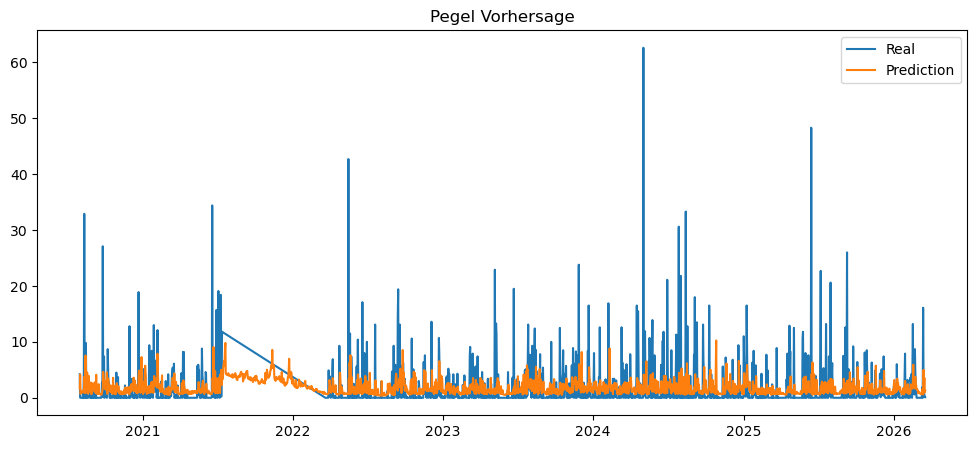

In [91]:
plt.figure(figsize=(12,5))
plt.plot(df_niederpegel["Datum"][df_niederpegel["Datum"] >= split_date], y_test, label="Real")
plt.plot(df_niederpegel["Datum"][df_niederpegel["Datum"] >= split_date], y_pred, label="Prediction")
plt.legend()
plt.title("Pegel Vorhersage")
plt.show()

Im ersten Run ein sehr schlechtes R^2, aber der plot sieht trotzdem okay aus für niedrige Werte. Modell sagt quasi, dass es bei hochwasser völlig daneben liegt, aber im niedrigen bereich belastbar ist. 

Bevor es weitergeht, lasse ich die feature importance prüfen.

In [92]:
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=features.columns).sort_values(ascending=False)

print(feat_imp)

t_minus7     0.192764
p_minus1     0.154956
t            0.148134
t_minus_3    0.142683
t_minus1     0.129372
p_minus7     0.116359
p_minus3     0.115733
dtype: float64


<Axes: title={'center': 'Feature Importance'}>

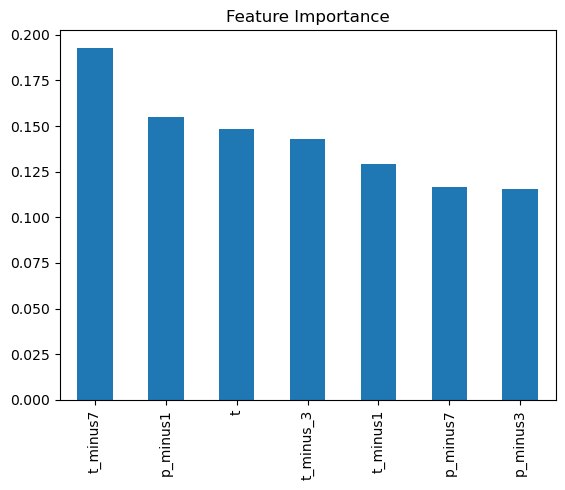

In [93]:
feat_imp.plot(kind="bar", title="Feature Importance")

p_minus1 dominiert die feature importance, damit war zu rechnen. Anschließend kann ich dp testen, also p- p-1 als Differenz. ob das geeigneter für hochwasser ist.

Die hohe Feature importance von t_minus7 finde ich interessant. Wetterlagen sind oft wechselhaft (ggfs im Wochentakt) und Effekte verzögert, vielleicht sollte man aber auch nicht zu viel hinein interpretieren, korrelation nicht gleich kausalität.

ich teste zuerst mit mehr lagged variables, also p_minus14, 21, 30, gleiches für n.

In [94]:
df_pegel_lagged = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Pegeldaten_Bonn_mitmehrlagged.csv", delimiter=";", header=0)

In [95]:
df_pegel_lagged["Datum"] = pd.to_datetime(df_pegel["Datum"], format="%d.%m.%Y")

In [96]:
df_niederschlag_lagged = pd.read_csv(r"C:\Users\Daniel Koch\Desktop\Fernerkundung\Remagen_Hochwasser\Daten\Niederschlag_Sinzig_mitmehrlagged.csv", delimiter=";", header=0)

df_niederschlag_lagged["Datum"] = pd.to_datetime(df_pegel["Datum"], format="%d.%m.%Y")

In [102]:
df_niederpegel_lagged = pd.merge(df_pegel_lagged, df_niederschlag_lagged, on="Datum")


df_niederpegel_lagged = df_niederpegel_lagged.sort_values("Datum") # nach datum sortieren

In [104]:
features_lagged = df_niederpegel_lagged[["p_minus1", "p_minus3", "p_minus7", "t", "t_minus1", "t_minus_3", "t_minus7", "p_minus14", "p_minus21", "p_minus30", "t_minus14", "t_minus21", "t_minus30"]]
target_lagged = df_niederpegel_lagged[["p"]]

In [107]:
df_niederpegel_lagged["Datum"]

0      2009-09-15
1      2009-09-16
2      2009-09-17
3      2009-09-18
4      2009-09-19
          ...    
6001   2026-02-19
6002   2026-02-20
6003   2026-02-21
6004   2026-02-22
6005   2026-02-23
Name: Datum, Length: 6006, dtype: datetime64[ns]

In [109]:
df_niederpegel_lagged = df_niederpegel_lagged.dropna()

X_lagged = features_lagged
y_lagged = target_lagged

HIER WEITER ANSETZEN. WARUM DER FEHLER? 

In [110]:


split_date = "2020-08-01"

X_train = X_lagged[df_niederpegel_lagged["Datum"] < split_date]
X_test  = X_lagged[df_niederpegel_lagged["Datum"] >= split_date]

y_train =  y_lagged[df_niederpegel_lagged["Datum"] < split_date]
y_test  = y_lagged[df_niederpegel_lagged["Datum"] >= split_date]

C:\Users\Daniel Koch\AppData\Local\Temp\ipykernel_5204\1656806202.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X_lagged[df_niederpegel_lagged["Datum"] < split_date]


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).